In [1]:
using Pkg
Pkg.activate("./env")
using ImportAll
using CSV
using Colors 
@importall(MarinePowerDynamics)
include("./src/plotexample.jl")
include("./src/savedata_minimal.jl")

  Activating project at `~/research/MarinePowerDynamics.jl/example/env`


plot_frequency_comparison

In [15]:
# pull in grid simulatio data and wave data
wec_flat = load_sim_data("wec_ieee14_flatrun_60s")
reg_flat = load_sim_data("ieee14_flatrun_60s")
wec_step = load_sim_data("wec_ieee14_stepchange_60s")
reg_step = load_sim_data("ieee14_stepchange_60s")

wave_data = CSV.read("./src/RM3_data/wave_data.csv", DataFrame)

ArgumentError: ArgumentError: "./simulation_results/wec_ieee14_flatrun_60s_data.csv" is not a valid file or doesn't exist

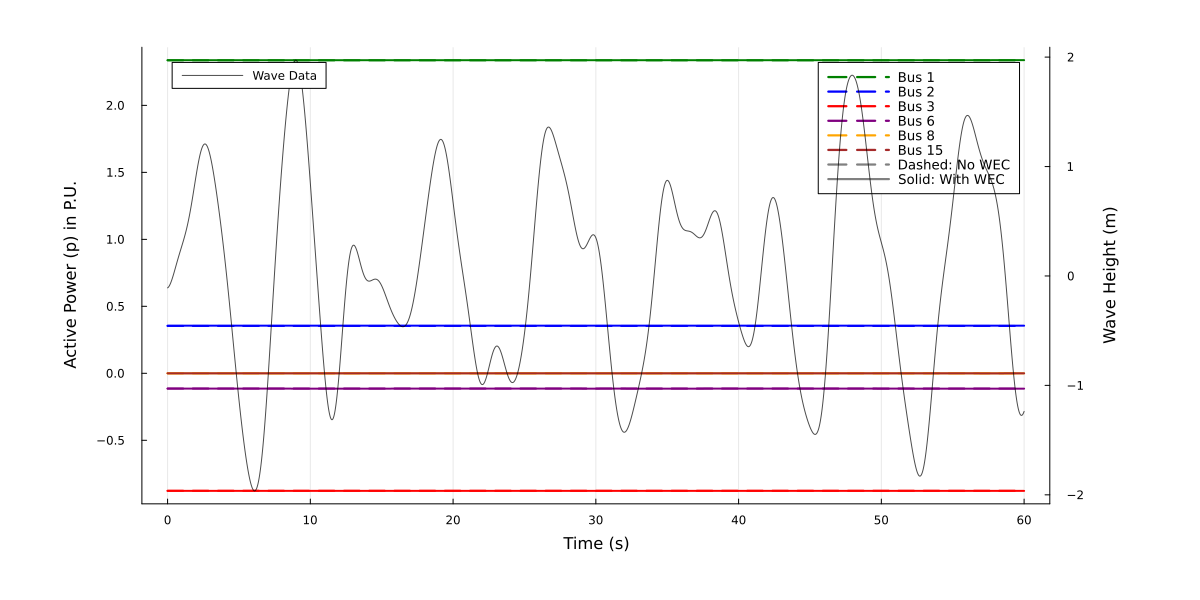

Plot recreated with buses 1,2,3,6,8,15
Dashed lines: No WEC case
Solid lines: With WEC case
Each bus uses consistent color across both cases

Bus 15 verification:
Bus 15 NOT found in regular grid data
Bus 15 found in WEC grid data - power range: -0.0 to -0.0 pu


In [3]:
# Recreate conference figure: Active Power Response at Buses 1,2,3,6,8 + Bus 15 (Flat Run)
# Dashed: No WEC, Solid: With WEC

using Plots

# Extract the DataFrames from the tuples
wec_flat_df = wec_flat[1]  # First element is the DataFrame
reg_flat_df = reg_flat[1]  # First element is the DataFrame

# Define buses to plot (matching conference figure + bus 15)
target_buses = ["bus1", "bus2", "bus3", "bus6", "bus8", "bus15"]

# Define colors for each bus (shared between WEC and no-WEC cases)
bus_colors = Dict(
    "bus1" => :green,
    "bus2" => :blue, 
    "bus3" => :red,
    "bus6" => :purple,
    "bus8" => :orange,
    "bus15" => :brown
)

# Create main plot for active power
p1 = plot(#title="Active Power Response at Buses 1,2,3,6,8 (Flat Run)", 
          title="", 
          xlabel="Time (s)", 
          ylabel="Active Power (p) in P.U.",
          legend=:topright,
          size=(1200, 600),
          grid=true,
          gridwidth=1,
          gridcolor=:lightgray,
          gridalpha=0.5,
          legendfontsize=9,
          framestyle=:box,
          frameon=true,
          box=:on,
          linewidth=2,
          margin=15Plots.mm,
          left_margin=20Plots.mm,
          bottom_margin=15Plots.mm,
          top_margin=10Plots.mm,
          right_margin=25Plots.mm,
          background_color_legend=RGBA(1,1,1,1),
          foreground_color_legend=:black)
# Plot No WEC data (dashed lines) - only label first occurrence for legend
for (i, bus) in enumerate(target_buses)
    col_name = "$(bus)_p"
    if col_name in names(reg_flat_df)
        # Only show bus number in legend, not line style
        bus_label = "Bus $(uppercase(bus[4:end]))"
        plot!(p1, reg_flat_df.time, reg_flat_df[!, col_name], 
              label=bus_label, 
              linestyle=:dash,
              color=bus_colors[bus],
              linewidth=2)
    else
        # For buses that don't exist in regular grid (like Bus 15), create empty label
        if bus == "bus15"
            bus_label = "Bus $(uppercase(bus[4:end]))"
            plot!(p1, Float64[], Float64[], 
                  label=bus_label, 
                  linestyle=:dash,
                  color=bus_colors[bus],
                  linewidth=2)
        end
    end
end

# Plot With WEC data (solid lines) - no labels to avoid duplication
for bus in target_buses
    col_name = "$(bus)_p"
    if col_name in names(wec_flat_df)
        plot!(p1, wec_flat_df.time, wec_flat_df[!, col_name], 
              label="", # No label to avoid legend duplication
              linestyle=:solid,
              color=bus_colors[bus],
              linewidth=2)
    end
end

# Add legend entries for line styles
plot!(p1, Float64[], Float64[], label="Dashed: No WEC", linestyle=:dash, color=:gray, linewidth=2)
plot!(p1, Float64[], Float64[], label="Solid: With WEC", linestyle=:solid, color=:gray, linewidth=2)

# Add wave data on secondary y-axis (trimmed to 60 seconds)
if !isempty(wave_data)
    # Create secondary y-axis for wave data
    p2 = twinx(p1)
    
    # Assume wave_data has time and wave_height columns (adjust column names as needed)
    wave_time_col = names(wave_data)[1]  # First column assumed to be time
    wave_data_col = names(wave_data)[2]  # Second column assumed to be wave data
    
    # Filter wave data to 60 seconds to match simulation timespan
    wave_mask = wave_data[!, wave_time_col] .<= 60.0
    wave_time_60s = wave_data[wave_mask, wave_time_col]
    wave_data_60s = wave_data[wave_mask, wave_data_col]
    
    plot!(p2, wave_time_60s, wave_data_60s,
          ylabel="Wave Height (m)",
          color=:black,
          linewidth=1,
          alpha=0.7,
          label="Wave Data",
          background_color_legend=RGBA(1,1,1,1),
          foreground_color_legend=:black)
end

# Ensure main plot legend is opaque
plot!(p1, background_color_legend=RGBA(1,1,1,1), foreground_color_legend=:black)

display(p1)

println("Plot recreated with buses 1,2,3,6,8,15")
println("Dashed lines: No WEC case")  
println("Solid lines: With WEC case")
println("Each bus uses consistent color across both cases")

# Verify Bus 15 is being plotted
println("\nBus 15 verification:")
if "bus15_p" in names(reg_flat_df)
    println("Bus 15 found in regular grid data - power range: $(round(minimum(reg_flat_df.bus15_p), digits=3)) to $(round(maximum(reg_flat_df.bus15_p), digits=3)) pu")
else
    println("Bus 15 NOT found in regular grid data")
end

if "bus15_p" in names(wec_flat_df)
    println("Bus 15 found in WEC grid data - power range: $(round(minimum(wec_flat_df.bus15_p), digits=3)) to $(round(maximum(wec_flat_df.bus15_p), digits=3)) pu")
else
    println("Bus 15 NOT found in WEC grid data")
end

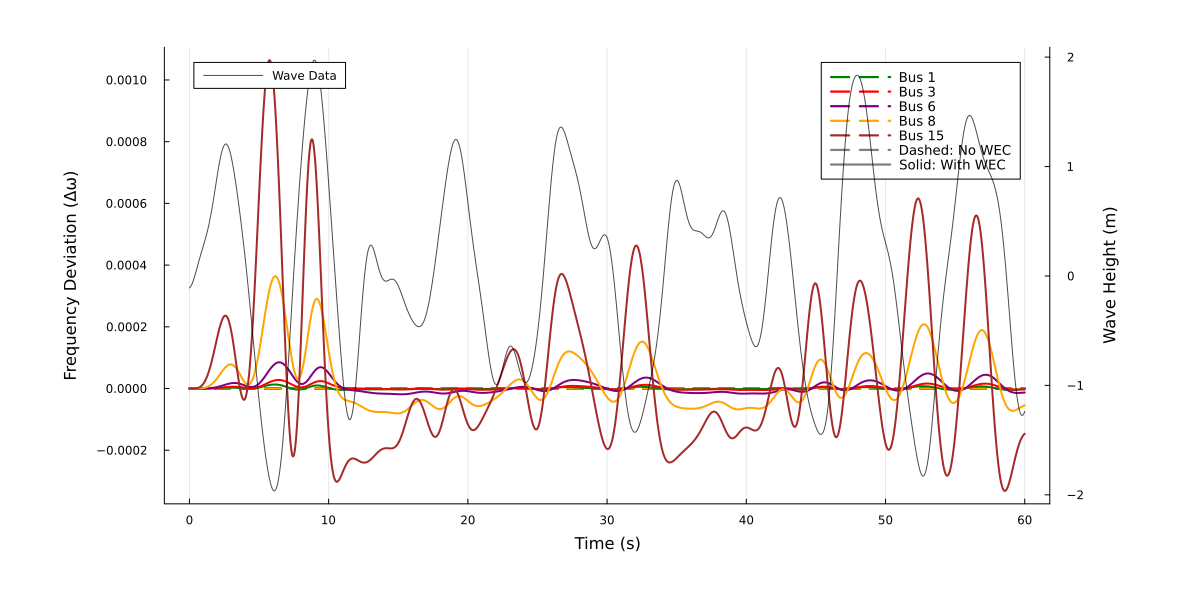

Frequency deviation plot created with buses 1,3,6,8,15
Dashed lines: No WEC case
Solid lines: With WEC case
Y-axis shows frequency deviation in pu from initial conditions

Bus 15 frequency verification:
Bus 15 NOT found in regular grid frequency data
Bus 15 found in WEC grid frequency data - deviation range: -0.000332 to 0.001064 pu


In [6]:
# Frequency deviation plot (matching conference figure style)
# Buses 1,3,6,8 + Bus 15 (Flat Run) - Dashed: No WEC, Solid: With WEC

# Define buses for frequency analysis (matching conference figure + bus 15)
freq_buses = ["bus1", "bus3", "bus6", "bus8", "bus15"]

# Use same colors as power plot for consistency
freq_colors = Dict(
    "bus1" => :green,
    "bus3" => :red,
    "bus6" => :purple,
    "bus8" => :orange,
    "bus15" => :brown
)

# Create main frequency plot
p3 = plot(title="", 
          xlabel="Time (s)", 
          ylabel="Frequency Deviation (Δω)",
          legend=:topright,
          size=(1200, 600),
          grid=true,
          gridwidth=1,
          gridcolor=:lightgray,
          gridalpha=0.5,
          legendfontsize=9,
          framestyle=:box,
          frameon=true,
          box=:on,
          linewidth=2,
          margin=15Plots.mm,
          left_margin=20Plots.mm,
          bottom_margin=15Plots.mm,
          top_margin=10Plots.mm,
          right_margin=25Plots.mm,
          background_color_legend=RGBA(1,1,1,1),
          foreground_color_legend=:black)

# Base frequency (60 Hz) - but we'll plot in pu deviation
f_base = 60.0

# Plot No WEC data (dashed lines) - frequency deviation from initial value
for (i, bus) in enumerate(freq_buses)
    col_name = "$(bus)_ω"
    if col_name in names(reg_flat_df)
        # Calculate frequency deviation from initial value (in pu)
        freq_dev_pu = reg_flat_df[!, col_name] .- reg_flat_df[1, col_name]
        bus_label = "Bus $(uppercase(bus[4:end]))"
        plot!(p3, reg_flat_df.time, freq_dev_pu, 
              label=bus_label, 
              linestyle=:dash,
              color=freq_colors[bus],
              linewidth=2)
    else
        # For buses that don't exist in regular grid (like Bus 15), create empty label
        if bus == "bus15"
            bus_label = "Bus $(uppercase(bus[4:end]))"
            plot!(p3, Float64[], Float64[], 
                  label=bus_label, 
                  linestyle=:dash,
                  color=freq_colors[bus],
                  linewidth=2)
        end
    end
end

# Plot With WEC data (solid lines) - no labels to avoid duplication
for bus in freq_buses
    col_name = "$(bus)_ω"
    if col_name in names(wec_flat_df)
        # Calculate frequency deviation from initial value (in pu)
        freq_dev_pu = wec_flat_df[!, col_name] .- wec_flat_df[1, col_name]
        plot!(p3, wec_flat_df.time, freq_dev_pu, 
              label="", # No label to avoid legend duplication
              linestyle=:solid,
              color=freq_colors[bus],
              linewidth=2)
    end
end

# Add legend entries for line styles
plot!(p3, Float64[], Float64[], label="Dashed: No WEC", linestyle=:dash, color=:gray, linewidth=2)
plot!(p3, Float64[], Float64[], label="Solid: With WEC", linestyle=:solid, color=:gray, linewidth=2)

# Add wave data on secondary y-axis
if !isempty(wave_data)
    # Create secondary y-axis for wave data
    p4 = twinx(p3)
    
    # Filter wave data to 60 seconds to match simulation timespan
    wave_time_col = names(wave_data)[1]  # First column assumed to be time
    wave_data_col = names(wave_data)[2]  # Second column assumed to be wave data
    
    wave_mask = wave_data[!, wave_time_col] .<= 60.0
    wave_time_60s = wave_data[wave_mask, wave_time_col]
    wave_data_60s = wave_data[wave_mask, wave_data_col]
    
    plot!(p4, wave_time_60s, wave_data_60s,
          ylabel="Wave Height (m)",
          color=:black,
          linewidth=1,
          alpha=0.7,
          label="Wave Data",
          background_color_legend=RGBA(1,1,1,1),
          foreground_color_legend=:black)
end

# Ensure main plot legend is opaque
plot!(p3, background_color_legend=RGBA(1,1,1,1), foreground_color_legend=:black)

display(p3)

println("Frequency deviation plot created with buses 1,3,6,8,15")
println("Dashed lines: No WEC case")  
println("Solid lines: With WEC case")
println("Y-axis shows frequency deviation in pu from initial conditions")

# Verify Bus 15 frequency data
println("\nBus 15 frequency verification:")
if "bus15_ω" in names(reg_flat_df)
    freq_range = reg_flat_df.bus15_ω .- reg_flat_df[1, "bus15_ω"]
    println("Bus 15 found in regular grid frequency data - deviation range: $(round(minimum(freq_range), digits=6)) to $(round(maximum(freq_range), digits=6)) pu")
else
    println("Bus 15 NOT found in regular grid frequency data")
end

if "bus15_ω" in names(wec_flat_df)
    freq_range = wec_flat_df.bus15_ω .- wec_flat_df[1, "bus15_ω"]
    println("Bus 15 found in WEC grid frequency data - deviation range: $(round(minimum(freq_range), digits=6)) to $(round(maximum(freq_range), digits=6)) pu")
else
    println("Bus 15 NOT found in WEC grid frequency data")
end

In [13]:
# Investigate plotexample.jl vs our CSV data approach
# Let's understand what plotexample.jl actually plots

println("=== Investigating plotexample.jl approach ===")

# First, let's see what the plotexample.jl function does
println("\nplotexample.jl analysis:")
println("- It looks for generator_indices with typeof(bus) == FourthOrderEq || typeof(bus) == LinearPTO")
println("- It plots generators, not buses!")
println("- Uses direct solution extraction: plot(sol, generator_indices, :p)")

# Let's check what our CSV saving captures vs direct solution
println("\n=== Our CSV data columns ===")
println("Regular step CSV columns: ", names(reg_step_df))

# Let's check if Bus8 is actually a generator or just a bus
println("\n=== Bus vs Generator investigation ===")
println("In our CSV, bus8_p shows: ", round(mean(reg_step_df.bus8_p[(reg_step_df.time .>= 30) .& (reg_step_df.time .<= 45)]), digits=4), " pu during fault")

# The key insight: plotexample.jl only plots GENERATORS, not buses
# But Bus 8 might be a load bus, not a generator bus
# So the step change affects the bus load, but we need to look at how generators respond

println("\n=== Key insight ===")
println("plotexample.jl only plots GENERATORS (FourthOrderEq, LinearPTO)")
println("But Bus 8 might be a LOAD bus, not a generator bus")
println("The step change adds 1.0 pu LOAD to Bus 8")
println("So we should see how the GENERATORS respond to this load change")

# Check what generator data we have
gen_cols_reg = filter(name -> !contains(string(name), "bus") && contains(string(name), "_p"), names(reg_step_df))
gen_cols_wec = filter(name -> !contains(string(name), "bus") && contains(string(name), "_p"), names(wec_step_df))

println("\nNon-bus power columns (likely generators):")
println("Regular: ", gen_cols_reg)
println("WEC: ", gen_cols_wec)

# If we have generator data, let's look at it during the step change
if !isempty(gen_cols_reg)
    println("\nGenerator response to Bus 8 step change:")
    for gen_col in gen_cols_reg[1:min(3, length(gen_cols_reg))]  # First few generators
        pre_fault = mean(reg_step_df[!, gen_col][reg_step_df.time .< 30])
        during_fault = mean(reg_step_df[!, gen_col][(reg_step_df.time .>= 30) .& (reg_step_df.time .<= 45)])
        gen_response = during_fault - pre_fault
        println("$(gen_col): $(round(pre_fault, digits=4)) → $(round(during_fault, digits=4)) (Δ = $(round(gen_response, digits=4)) pu)")
    end
end

=== Investigating plotexample.jl approach ===

plotexample.jl analysis:
- It looks for generator_indices with typeof(bus) == FourthOrderEq || typeof(bus) == LinearPTO
- It plots generators, not buses!
- Uses direct solution extraction: plot(sol, generator_indices, :p)

=== Our CSV data columns ===


UndefVarError: UndefVarError: `reg_step_df` not defined